In [1]:
# use float64'
from jax import config
config.update("jax_enable_x64", True)

In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr
import optax

from hybrid_models.hh import *
from hybrid_models.hh import integrate
from hybrid_models.utils import tree_path_of_leaves, tree_set_with_path, tree_filter_by_path, Dataset
from hybrid_models.transforms import ParamTransform, LogisticTransform, ModelParamTransform
import equinox as eqx

import matplotlib.pyplot as plt

import os
import sys
sys.path.append('../')
import pickle

from scripts.configs import *
config = train_hybrid_on_multicomp()
import diffrax

import json

import numpy as np
import re
from scipy.stats import gaussian_kde

FULL_WIDTH = 5.521
HALF_WIDTH = FULL_WIDTH / 2
plt.style.use("../.matplotlibrc")

In [3]:
timestamp_pattern = r"_\d{4}_\d{2}_\d{2}_\d{2}_\d{2}_\d{2}_\d{6}(?=\.json$)"
results_dirpath = "../results/sweeps/icg11"

fnames = [f for f in os.listdir(results_dirpath) if f.endswith(".json")]
fpaths_old = [os.path.join(results_dirpath, fname) for fname in fnames]
fpaths_new = [re.sub(timestamp_pattern, "",  f) for f in fpaths_old]
for f_old, f_new in zip(fpaths_old, fpaths_new):
    os.rename(f_old, f_new)

In [4]:
def stack_at_leaf_lvl(tree):
    out = {}
    for key in tree[0].keys():  # 'tau', 'xinf'
        leaves = []
        for d in tree:
            leaves.extend(d[key].values())  # ignore inner keys
        out[key] = jnp.stack(leaves)
    return out

In [5]:
results_dirpath = "../results/sweeps/icg11"
data_dirpath = "../data/icg_channels"

mse = lambda x,y : jnp.mean((x - y) ** 2)
rel_mse = lambda x,y : jnp.mean((x - y) ** 2 / (y ** 2 + 1e-8))
error_fn = mse

data_fpaths = []
for root, _, files in os.walk(data_dirpath):
    for fname in files:
        if fname.endswith(".json"):
            data_fpaths.append(os.path.join(root, fname))

plot_data = {"node_err": [], "omni_err": [], "node_pred": [], "omni_pred": [], "data": [], "name": [], "states": []}
failed_fits = []

for fpath in data_fpaths:
    fname = os.path.basename(fpath)
    
    data = Dataset.from_file(fpath)
    states = data.metadata["states"]
    omni_pred = data.metadata["omni"]
    val_data = data.Y

    omni_errs = {}
    top_om = None
    if data.metadata["fit"]:
        for om in omni_pred.keys():
            rel_omni_errs = jax.tree.map(rel_mse, val_data, omni_pred[om])
            omni_errs[om] = jax.tree.reduce(lambda x,y: x + y, rel_omni_errs)
        top_om = min(omni_errs, key=omni_errs.get)
    else:
        failed_fits.append(fpath)
    
    if top_om is not None:
        omni_errs = jax.tree.map(error_fn, val_data, omni_pred[top_om])
        omni_pred = omni_pred[top_om]
    else:
        omni_errs = jax.tree.map(lambda x: jnp.inf, val_data)
        omni_pred = jax.tree.map(lambda x: jnp.full_like(x, jnp.nan), val_data)

    plot_data["omni_err"].append(omni_errs)
    plot_data["omni_pred"].append(omni_pred)
    plot_data["data"].append(val_data)
    plot_data["states"] += states
    plot_data["name"] += [fname.replace(".json", "")]*len(states)

    # node fits
    try: # TODO: REMOVE THIS IS TEMPORARY
        res_fpath = os.path.join(results_dirpath, fname)
        with open(res_fpath, "r") as f:
            result = json.load(f)
            if "validation_data" in result:
                result = result["validation_data"]
                result = jax.tree.map(lambda x: jnp.array(x), result, is_leaf=lambda x: isinstance(x, list))
                node_pred = result["pred"]
            else:
                node_pred = jax.tree.map(lambda x: jnp.full_like(x, jnp.nan), val_data) 

        node_errs = jax.tree.map(error_fn, val_data, node_pred)
        
        plot_data["node_err"].append(node_errs)
        plot_data["node_pred"].append(node_pred)
    except Exception as e:
        dummy_errs = jax.tree.map(lambda x: jnp.inf, val_data)
        dummy_pred = jax.tree.map(lambda x: jnp.full_like(x, jnp.nan), val_data)
        plot_data["node_err"].append(dummy_errs)
        plot_data["node_pred"].append(dummy_pred)
        print(f"Error loading node results for {fname}: {e}")

plot_data["node_pred"] = stack_at_leaf_lvl(plot_data["node_pred"])
plot_data["node_err"] = stack_at_leaf_lvl(plot_data["node_err"])
plot_data["omni_err"] = stack_at_leaf_lvl(plot_data["omni_err"])
plot_data["omni_pred"] = stack_at_leaf_lvl(plot_data["omni_pred"])
plot_data["data"] = stack_at_leaf_lvl(plot_data["data"])

Error loading node results for 144490_hha_old_v2.json: Dict key mismatch; expected keys: ['n']; present keys: ['m'].
Error loading node results for 144490_hha_old.json: Dict key mismatch; expected keys: ['n']; present keys: ['m'].
Error loading node results for 156120_hh1.json: Dict key mismatch; expected keys: ['n']; present keys: ['h', 'm'].
Error loading node results for 155157_HH_traub.json: Dict key mismatch; expected keys: ['n']; present keys: ['h'].
Error loading node results for 136176_hh3.json: Dict key mismatch; expected keys: ['n', 's']; present keys: ['h', 'm', 's'].
Error loading node results for 114047_hh.json: Dict key mismatch; expected keys: ['n']; present keys: ['h', 'm'].
Error loading node results for 20212_hha2.json: Dict key mismatch; expected keys: ['n']; present keys: ['h', 'm'].
Error loading node results for 19214_hh1.json: Dict key mismatch; expected keys: ['n']; present keys: ['h', 'm'].
Error loading node results for 144490_hha2_v2.json: Dict key mismatch; 

In [9]:
num_channels = len(np.unique(plot_data["name"]))

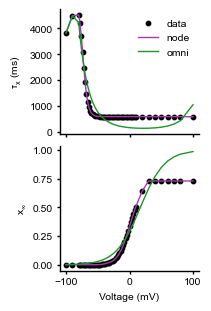

In [113]:
C1 = "#a838b2"
C2 = "#1D952D"

node_errs = plot_data["node_err"]
omni_errs = plot_data["omni_err"]

error_diff_tau = node_errs["tau"] - omni_errs["tau"]
error_diff_xinf = node_errs["xinf"] - omni_errs["xinf"]

top10_tau_errors = jnp.argsort(error_diff_tau[jnp.isfinite(error_diff_tau)])[:10]
top10_xinf_errors = jnp.argsort(error_diff_xinf[jnp.isfinite(error_diff_xinf)])[:10]

node_tau_no_inf = plot_data["node_pred"]["tau"][jnp.isfinite(error_diff_tau)]
omni_tau_no_inf = plot_data["omni_pred"]["tau"][jnp.isfinite(error_diff_tau)]
data_tau_no_inf = plot_data["data"]["tau"][jnp.isfinite(error_diff_tau)]

node_xinf_no_inf = plot_data["node_pred"]["xinf"][jnp.isfinite(error_diff_xinf)]
omni_xinf_no_inf = plot_data["omni_pred"]["xinf"][jnp.isfinite(error_diff_xinf)]
data_xinf_no_inf = plot_data["data"]["xinf"][jnp.isfinite(error_diff_xinf)]

vs = jnp.array([-100.,  -90., *list(range(-80, 10, 2)), *list(range(10, 80, 10)), 80., 100.])

k_tau = 4
k_xinf = 4

fig, axes = plt.subplots(2, 1, layout="constrained", figsize=(2, 3), sharex=True)
axes[0].scatter(vs, data_tau_no_inf[top10_tau_errors][k_tau], label="data", color="k", s=10)
axes[0].plot(vs, node_tau_no_inf[top10_tau_errors][k_tau], label="node", color=C1)
axes[0].plot(vs, omni_tau_no_inf[top10_tau_errors][k_tau], label="omni", color=C2)
axes[0].set_clip_on(False)
axes[0].set_ylabel(r"$\tau_x$ (ms)")
axes[0].legend()

axes[1].scatter(vs, data_xinf_no_inf[top10_xinf_errors][k_xinf], label="data", color="k", s=10)
axes[1].plot(vs, node_xinf_no_inf[top10_xinf_errors][k_xinf], label="node", color=C1)
axes[1].plot(vs, omni_xinf_no_inf[top10_xinf_errors][k_xinf], label="omni", color=C2)

# axins = axes[1].inset_axes([0.5, 0.25, 0.4, 0.4])
# axins.scatter(vs, plot_data["data"]["xinf"][top10_xinf_errors][k_xinf], color="k", s=10)
# axins.plot(vs, node_xinf_no_inf[top10_xinf_errors][k_xinf], color=C1)
# axins.plot(vs, omni_xinf_no_inf[top10_xinf_errors][k_xinf], color=C2)
# axins.set_xlim(50, 100)
# axins.set_ylim(0.99, 1.001)  # xinf usually approaches 1 at high voltages
# axins.set_xticks([50, 100])
# axins.set_yticks([0.99, 1.0])
# axins.set_clip_on(False)
# axes[1].indicate_inset_zoom(axins, edgecolor="black")

axes[1].set_ylabel(r"$x_{\infty}$")
axes[1].set_xlabel("Voltage (mV)")
axes[1].set_clip_on(False)

In [ ]:
num_node = node_errs.shape[0] 
num_omni = omni_errs.shape[0]

diff = num_node - num_omni
print(f"NODE gets {diff} more fits than OMNI")

NODE gets 183 more fits than omni


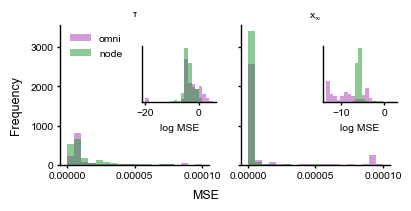

In [8]:
C1 = "#a838b2"
C2 = "#1D952D"

fig, axes = plt.subplots(1, 2, layout="constrained", figsize=(4, 2), sharey=True)
for ax, key, title in zip(axes, ["tau", "xinf"], [r"$\tau$", r"$x_{\infty}$"]):
    
    omni_errs = plot_data["omni_err"][key] + 1e-20 # add small constant to avoid log(0)
    node_errs = plot_data["node_err"][key] + 1e-20 # add small constant to avoid log(0)
    omni_errs = omni_errs[jnp.isfinite(omni_errs)] # & (omni_errs > -21)
    node_errs = node_errs[jnp.isfinite(node_errs)] # & (node_errs > -21)

    # x_min = min(omni.min(), node.min())
    # x_max = max(omni.max(), node.max())
    # bins = np.linspace(x_min, x_max, 20)
    bins = np.linspace(0, 0.0001, 20)

    ax.hist(omni_errs, bins=bins, alpha=0.5, label="omni", color=C1)
    ax.hist(node_errs, bins=bins, alpha=0.5, label="node", color=C2)

    inset_ax = ax.inset_axes([0.55, 0.45, 0.50, 0.40])


    omni_errs_log = jnp.log10(omni_errs)
    node_errs_log = jnp.log10(node_errs)

    x_min = min(omni_errs_log.min(), node_errs_log.min())
    x_max = max(omni_errs_log.max(), node_errs_log.max())
    bins_log = np.linspace(x_min, x_max, 20)

    inset_ax.hist(omni_errs_log, bins=bins_log, alpha=0.5, color=C1)
    inset_ax.hist(node_errs_log, bins=bins_log, alpha=0.5, color=C2)
    inset_ax.set_xlabel("log MSE")
    inset_ax.set_yticks([])

    inset_ax.tick_params(axis="both")

    ax.set_title(title)

axes[0].legend(loc="upper left")
fig.supxlabel("MSE")
fig.supylabel("Frequency")
plt.show()

In [8]:
vs = jnp.array([-100.,  -90., *list(range(-80, 10, 2)), *list(range(10, 80, 10)), 80., 100.])

failed_fits_plotting = {"data": [], "pred": [], "errs": [], "name": []}
for fpath in failed_fits[:10]:
    fname = os.path.basename(fpath)
    
    data = Dataset.from_file(fpath)
    states = data.metadata["states"]
    omni_pred = data.metadata["omni"]
    val_data = data.Y

    # node fits
    try: # TODO: REMOVE THIS IS TEMPORARY
        res_fpath = os.path.join(results_dirpath, fname)
        with open(res_fpath, "r") as f:
            result = json.load(f)
            if "validation_data" in result:
                result = result["validation_data"]
                result = jax.tree.map(lambda x: jnp.array(x), result, is_leaf=lambda x: isinstance(x, list))
                node_pred = result["pred"]
            else:
                node_pred = jax.tree.map(lambda x: jnp.full_like(x, jnp.nan), val_data) 

        node_errs = jax.tree.map(error_fn, val_data, node_pred)

        failed_fits_plotting["data"].append(val_data)
        failed_fits_plotting["pred"].append(node_pred)
        failed_fits_plotting["errs"].append(node_errs)
        failed_fits_plotting["name"].append(fname.replace(".json", ""))

    except Exception as e:
        print(f"Error loading node results for {fname}: {e}")

Error loading node results for 144490_hha_old_v2.json: Dict key mismatch; expected keys: ['n']; present keys: ['m'].
Error loading node results for 144490_hha_old.json: Dict key mismatch; expected keys: ['n']; present keys: ['m'].
Error loading node results for 20212_hha2.json: Dict key mismatch; expected keys: ['n']; present keys: ['h', 'm'].
Error loading node results for 144490_hha2_v2.json: Dict key mismatch; expected keys: ['n']; present keys: ['h', 'm'].
Error loading node results for 119266_hha_old.json: Dict key mismatch; expected keys: ['n']; present keys: ['m'].


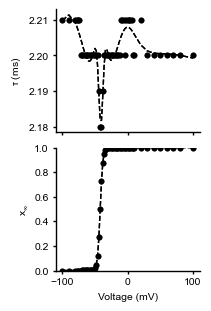

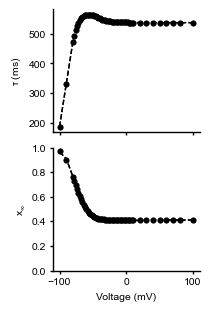

In [9]:
k = 1
node_pred = failed_fits_plotting["pred"][k]
val_data = failed_fits_plotting["data"][k]
states = plot_data["states"][:len(node_pred["tau"])]

fig, axes = plt.subplots(2, len(val_data["tau"]), layout="constrained", figsize=(2, 3), sharex=True)
for i, ax in enumerate(axes.T):
    for state in val_data["tau"].keys():
        axes[0].plot(vs, node_pred["tau"][state], label="pred", color="k", ls="--")
        axes[0].scatter(vs, val_data["tau"][state], label="data", color="k", s=10)
        axes[0].set_ylabel(r"$\tau$ (ms)")
        
        axes[1].plot(vs, node_pred["xinf"][state], label="pred", color="k", ls="--")
        axes[1].scatter(vs, val_data["xinf"][state], label="data", color="k", s=10)
        axes[1].set_ylabel(r"$x_{\infty}$")
        axes[1].set_ylim(0, 1)
        axes[1].set_xlabel("Voltage (mV)")

k = 4
node_pred = failed_fits_plotting["pred"][k]
val_data = failed_fits_plotting["data"][k]
states = plot_data["states"][:len(node_pred["tau"])]

fig, axes = plt.subplots(2, len(val_data["tau"]), layout="constrained", figsize=(2, 3), sharex=True)
for i, ax in enumerate(axes.T):
    for state in val_data["tau"].keys():
        axes[0].plot(vs, node_pred["tau"][state], label="pred", color="k", ls="--")
        axes[0].scatter(vs, val_data["tau"][state], label="data", color="k", s=10)
        axes[0].set_ylabel(r"$\tau$ (ms)")
        
        axes[1].plot(vs, node_pred["xinf"][state], label="pred", color="k", ls="--")
        axes[1].scatter(vs, val_data["xinf"][state], label="data", color="k", s=10)
        axes[1].set_ylabel(r"$x_{\infty}$")
        axes[1].set_ylim(0, 1)
        axes[1].set_xlabel("Voltage (mV)")

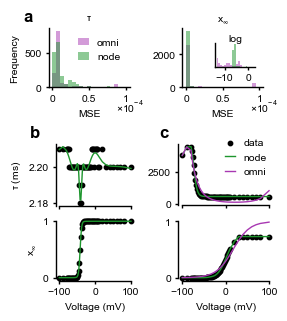

In [11]:
C1 = "#a838b2"
C2 = "#1D952D"

def panel_label(ax, label, x=-0.12, y=1.07):
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="bottom",
        ha="right",
    )

fig = plt.figure(figsize=(HALF_WIDTH, 3.1), layout="constrained")
# Add a dummy row in the middle to act as vertical space
gs = fig.add_gridspec(3, 1, height_ratios=[1, 0.15, 1.5])

# -------------------------
# Panel a (Histograms)
# -------------------------
gs_a = gs[0].subgridspec(1, 2)
axes_a = [fig.add_subplot(gs_a[0, 0]), fig.add_subplot(gs_a[0, 1])]
# axes_a[1].sharey(axes_a[0])

for ax, key, title in zip(axes_a, ["tau", "xinf"], [r"$\tau$", r"$x_{\infty}$"]):
    
    omni_errs = plot_data["omni_err"][key] + 1e-20
    node_errs = plot_data["node_err"][key] + 1e-20
    omni_errs = omni_errs[jnp.isfinite(omni_errs)]
    node_errs = node_errs[jnp.isfinite(node_errs)]

    bins = np.linspace(0, 0.0001, 20)

    ax.hist(omni_errs, bins=bins, alpha=0.5, label="omni", color=C1)
    ax.hist(node_errs, bins=bins, alpha=0.5, label="node", color=C2)
    ax.set_xticks([0, 0.00005, 0.0001])
    # ax.set_xlim(0, 0.00013)
    ax.set_xticklabels(["0", "0.5", "1"])
    ax.text(1.18, -0.18, r"$\times 10^{-4}$", transform=ax.transAxes, ha="right", va="top")

    if key == "xinf":
        inset_ax = ax.inset_axes([0.4, 0.35, 0.50, 0.40])

        omni_errs_log = jnp.log10(omni_errs)
        node_errs_log = jnp.log10(node_errs)

        x_min = min(omni_errs_log.min(), node_errs_log.min())
        x_max = max(omni_errs_log.max(), node_errs_log.max())
        bins_log = np.linspace(x_min, x_max, 20)

        inset_ax.hist(omni_errs_log, bins=bins_log, alpha=0.5, color=C1)
        inset_ax.hist(node_errs_log, bins=bins_log, alpha=0.5, color=C2)
        inset_ax.set_title("log", pad=0)
        inset_ax.set_yticks([])
        inset_ax.tick_params(axis="both")

    ax.set_title(title)

axes_a[0].set_xlabel("MSE")
axes_a[1].set_xlabel("MSE")
axes_a[0].set_ylabel("Frequency")
axes_a[0].legend(loc="upper right", handlelength=1)

panel_label(axes_a[0], "a", x=-0.2, y=1.07)

# -------------------------
# Panel b (Examples)
# -------------------------
gs_b = gs[2].subgridspec(1, 2)
examples = [1]

for idx, k in enumerate(examples):
    node_pred = failed_fits_plotting["pred"][k]
    val_data = failed_fits_plotting["data"][k]
    n_states = len(val_data["tau"])
    
    gs_inner = gs_b[idx].subgridspec(2, n_states)
    
    for i, state in enumerate(val_data["tau"].keys()):
        ax0 = fig.add_subplot(gs_inner[0, i])
        ax1 = fig.add_subplot(gs_inner[1, i])
        
        ax0.scatter(vs, val_data["tau"][state], label="data", color="k", s=10)
        ax0.plot(vs, node_pred["tau"][state], label="pred", color=C2)
        ax0.set_xticks([-100, 0, 100])
        ax0.set_xticklabels([])
        
        ax1.scatter(vs, val_data["xinf"][state], label="data", color="k", s=10)
        ax1.plot(vs, node_pred["xinf"][state], label="pred", color=C2)
        
        if idx == 0 and i == 0:
            ax0.set_ylabel(r"$\tau$ (ms)")
            ax1.set_ylabel(r"$x_{\infty}$")
        ax1.set_xlabel("Voltage (mV)")
        ax1.set_xticks([-100, 0, 100])
        
        ax0.spines["bottom"].set_bounds(vs.min(), vs.max())
        ax0.spines["left"].set_bounds(*ax0.get_ylim())
        ax1.spines["bottom"].set_bounds(vs.min(), vs.max())
        ax1.spines["left"].set_bounds(0, 1)
        
        if idx == 0 and i == 0:
            # Recreate panel_label logic but set in_layout=False so it doesn't shrink the column
            ax0.text(
                -0.2,
                1.05,
                "b",
                transform=ax0.transAxes,
                fontsize=12,
                fontweight="bold",
                va="bottom",
                ha="right",
                in_layout=False,
            )

# -------------------------
# Panel c
# -------------------------
gs_c = gs_b[1].subgridspec(2, 1)
axes_c = [fig.add_subplot(gs_c[0]), fig.add_subplot(gs_c[1])]
# axes_c[1].sharex(axes_c[0])

error_diff_tau = plot_data["node_err"]["tau"] - plot_data["omni_err"]["tau"]
error_diff_xinf = plot_data["node_err"]["xinf"] - plot_data["omni_err"]["xinf"]

top10_tau_errors = jnp.argsort(error_diff_tau[jnp.isfinite(error_diff_tau)])[:10]
top10_xinf_errors = jnp.argsort(error_diff_xinf[jnp.isfinite(error_diff_xinf)])[:10]

node_tau_no_inf = plot_data["node_pred"]["tau"][jnp.isfinite(error_diff_tau)]
omni_tau_no_inf = plot_data["omni_pred"]["tau"][jnp.isfinite(error_diff_tau)]
data_tau_no_inf = plot_data["data"]["tau"][jnp.isfinite(error_diff_tau)]

node_xinf_no_inf = plot_data["node_pred"]["xinf"][jnp.isfinite(error_diff_xinf)]
omni_xinf_no_inf = plot_data["omni_pred"]["xinf"][jnp.isfinite(error_diff_xinf)]
data_xinf_no_inf = plot_data["data"]["xinf"][jnp.isfinite(error_diff_xinf)]

k_tau = 4
k_xinf = 4

axes_c[0].scatter(vs, data_tau_no_inf[top10_tau_errors][k_tau], label="data", color="k", s=10)
axes_c[0].plot(vs, node_tau_no_inf[top10_tau_errors][k_tau], label="node", color=C2)
axes_c[0].plot(vs, omni_tau_no_inf[top10_tau_errors][k_tau], label="omni", color=C1)
axes_c[0].set_xticks([-100, 0, 100])
axes_c[0].set_xticklabels([])
axes_c[0].set_clip_on(False)
# axes_c[0].set_ylabel(r"$\tau_x$ (ms)")
leg = axes_c[0].legend(loc=(0.45, 0.40), handlelength=1)
leg.set_in_layout(False)

axes_c[1].scatter(vs, data_xinf_no_inf[top10_xinf_errors][k_xinf], label="data", color="k", s=10)
axes_c[1].plot(vs, node_xinf_no_inf[top10_xinf_errors][k_xinf], label="node", color=C2)
axes_c[1].plot(vs, omni_xinf_no_inf[top10_xinf_errors][k_xinf], label="omni", color=C1)

# axes_c[1].set_ylabel(r"$x_{\infty}$")
axes_c[1].set_xlabel("Voltage (mV)")
axes_c[1].set_xticks([-100, 0, 100])
axes_c[1].set_clip_on(False)

axes_c[0].spines["bottom"].set_bounds(vs.min(), vs.max())
axes_c[0].spines["left"].set_bounds(*axes_c[0].get_ylim())
axes_c[1].spines["bottom"].set_bounds(vs.min(), vs.max())
axes_c[1].spines["left"].set_bounds(0, 1)

axes_c[0].text(
    -0.1,
    1.05,
    "c",
    transform=axes_c[0].transAxes,
    fontsize=12,
    fontweight="bold",
    va="bottom",
    ha="right",
    in_layout=False,
)

plt.savefig("../figures/paper/fig2.pdf", dpi=300, transparent=True)
plt.savefig("../figures/paper/fig2.png", dpi=300, transparent=True)